## Hands-on Task 3: Simulating Multiple Clients

In [ ]:
import sklearn
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

def partition_data(X, y, num_clients, mode, seed):
    rng = np.random.default_rng(seed)#随机数生成

    if mode == "IID":
        indices = rng.permutation(len(y))#随机打乱样本编号
    elif mode == "non-IID":
        indices = np.concatenate([
            rng.permutation(np.flatnonzero(y == label)) #随机打乱各个label中的样本编号
            for label in np.unique(y)
        ])
    else:
        raise ValueError("No such mode")
    
    #把样本编号给客户端
    client_indices = np.array_split(indices,num_clients)
    return [(X[idx],y[idx]) for idx in client_indices]


In [ ]:
iid_clients = partition_data(X, y, 5, "IID", 47)
non_iid_clients = partition_data(X, y, 5, "non-IID", 47)


for mode_name, clients in [
    ("IID", iid_clients),
    ("non-IID", non_iid_clients),
]:
    print(f"\n===== {mode_name} =====")

    for client_id, (X_client, y_client) in enumerate(clients):
        labels, counts = np.unique(y_client, return_counts=True)
        class_distribution = dict(zip(labels.tolist(), counts.tolist()))

        print(f"\nClient {client_id}")
        print("样本数：", len(y_client))
        print("类别分布：", class_distribution)
        print("特征均值：", np.round(X_client.mean(axis=0), 2))
        print("特征标准差：", np.round(X_client.std(axis=0), 2))

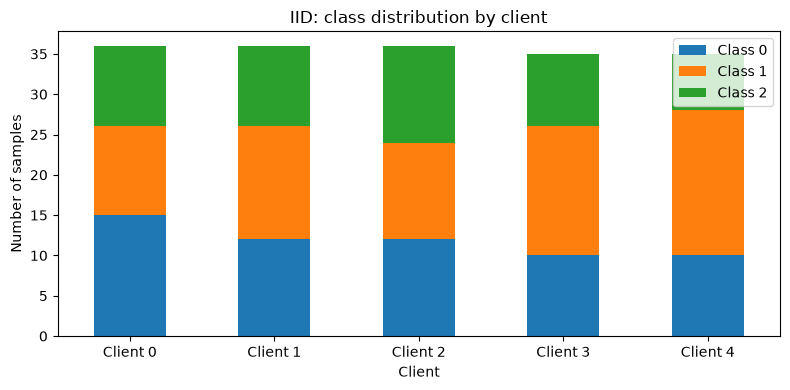

In [5]:
iid_counts = np.array([
    np.bincount(iid_clients[0][1], minlength=3),
    np.bincount(iid_clients[1][1], minlength=3),
    np.bincount(iid_clients[2][1], minlength=3),
    np.bincount(iid_clients[3][1], minlength=3),
    np.bincount(iid_clients[4][1], minlength=3),
])

iid_table = pd.DataFrame(
    iid_counts,
    index=["Client 0", "Client 1", "Client 2", "Client 3", "Client 4"],
    columns=["Class 0", "Class 1", "Class 2"],
)

iid_table.plot.bar(stacked=True, figsize=(8, 4))
plt.title("IID: class distribution by client")
plt.xlabel("Client")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

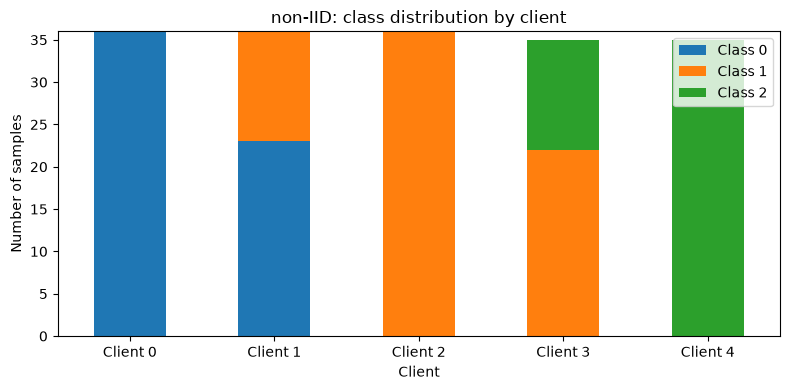

In [6]:
non_iid_counts = np.array([
    np.bincount(non_iid_clients[0][1], minlength=3),
    np.bincount(non_iid_clients[1][1], minlength=3),
    np.bincount(non_iid_clients[2][1], minlength=3),
    np.bincount(non_iid_clients[3][1], minlength=3),
    np.bincount(non_iid_clients[4][1], minlength=3),
])

non_iid_table = pd.DataFrame(
    non_iid_counts,
    index=["Client 0", "Client 1", "Client 2", "Client 3", "Client 4"],
    columns=["Class 0", "Class 1", "Class 2"],
)

non_iid_table.plot.bar(stacked=True, figsize=(8, 4))
plt.title("non-IID: class distribution by client")
plt.xlabel("Client")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Explain why client heterogeneity may make collaborative learning difficult.

Ans: Because in non-IID partition, clients have different class distributions. Some clients contain mainly one class, so their models learn mostly from that class. When the clients’ updates are combined, the updates may point in different directions. As a result, collaborative training may converge more slowly and the final model may perform unbalancely across classes.